In [1]:
from nilearn import datasets, plotting
import nibabel as nib
import pandas as pd
import nilearn
import matplotlib.pyplot as plt
import pickle
import numpy as np
import os.path as op
import seaborn as sns

In [2]:
schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100) 

[fetch_atlas_schaefer_2018] Dataset found in /global/homes/m/mphagen/nilearn_data/schaefer_2018


In [3]:
lasso_acc_df = pd.read_csv('/global/homes/m/mphagen/functional-connectivity/connectome-comparison/results/intermediate_results/2025-12-10_r2_lasso_xcpd.csv')
lasso_mean_node_df = lasso_acc_df.set_index(['node', 'fold']).groupby('node').mean() 

In [4]:
analysis_results = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/scripts/notebooks/02-Analysis/results' 

In [5]:
lasso_icc_lme_df = pd.read_csv(op.join(analysis_results, 'lasso_xcpd_lme_icc.csv'), header=None).loc[1]
lasso_icc_lme_array =  np.array(pd.to_numeric(lasso_icc_lme_df))

In [6]:
corr_icc_lme_df = pd.read_csv(op.join(analysis_results, 'pearson_xcpd_lme_icc.csv'), header=None).loc[1]
corr_icc_lme_array =  np.array(pd.to_numeric(corr_icc_lme_df))

In [7]:
lasso_pkl_file = '/global/homes/m/mphagen/functional-connectivity/connectome-comparison/scripts/notebooks/02-Analysis/xcpd_lasso_icc.pkl' 

just checkout anova and lme corerlations real quick

In [11]:
with open(lasso_pkl_file, 'rb') as file: 
    icc_pkl = pickle.load(file) 

In [14]:
lasso_icc_anova_array = []
for ii in icc_pkl.keys(): 
    lasso_icc_anova_array.append(icc_pkl[ii].loc[5]['ICC']) 
lasso_icc_anova_array = np.array(icc_anova_array)

In [15]:
pd.DataFrame([lasso_icc_anova_array, lasso_icc_lme_array]).T.corr() 

,0,1
0,1.000000,0.884238
1,0.884238,1.000000


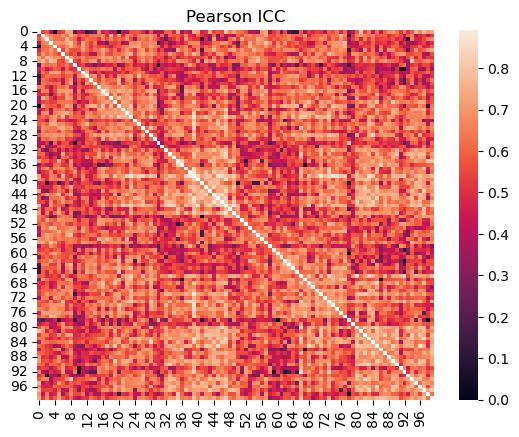

In [18]:
sns.heatmap(corr_icc_lme_array.reshape(100,100)) 
plt.title('Pearson ICC') 
plt.savefig('pearson_icc.png')

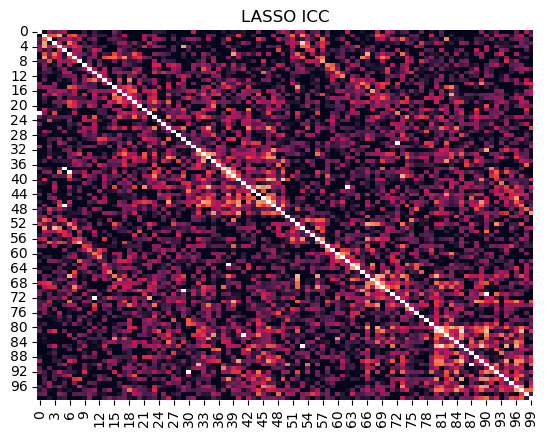

In [24]:
# fig, ax = plt.subplot(1, 1, figsize=(10,10))
sns.heatmap(lasso_icc_lme_array.reshape(100,100), vmax=.8, cbar=False) 
plt.title('LASSO ICC') 
plt.savefig('lasso_icc.png')

#### random plotting

In [39]:
atlas_file = schaefer['maps']


In [ ]:

# atlas = nib.load(atlas_file) 
# atlas = nib.load(atlas_file) 
# xcpd_atlas = atlas.get_fdata()

# for ii in lasso_mean_df.index: 
#         #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
#         #find where each node is labeled 
#         node_loc = np.isin(nilearn.image.get_data(atlas),
#                            (int(ii.replace('node_', '')) + 1)) 
#         #and change it to the acc_value
#         xcpd_atlas[node_loc ] = lasso_mean_df.loc[ii]


In [ ]:
# mask_img = nilearn.image.new_img_like(atlas, xcpd_atlas)
# plotting.plot_stat_map(
# mask_img,vmax=1, vmin=-1, cmap='berlin', display_mode='mosaic', title='corr(r2, motion')  
# plt.savefig('accuracy_motion_correlation_spatial.png') 
# plotting.show()

In [ ]:
# icc_node_mean = (np.nanmean(icc_mat, axis=0) + np.nanmean(icc_mat, axis=1)) / 2


In [ ]:
# icc_row_mean = np.nanmean(icc_mat, axis=0) 
# icc_col_mean = np.nanmean(icc_mat, axis=1) 

In [40]:
atlas = nib.load(atlas_file) 
xcpd_atlas = atlas.get_fdata()

for ii in range(0,100): 
        #xcpd_atlas is 1 indexed, xcpd_node_df is 0 indexed
        #find where each node is labeled 
        node_loc = np.isin(nilearn.image.get_data(atlas),
                           (ii + 1)) 
        #and change it to the acc_value
        xcpd_atlas[node_loc ] = icc_lme_node_array[ii]


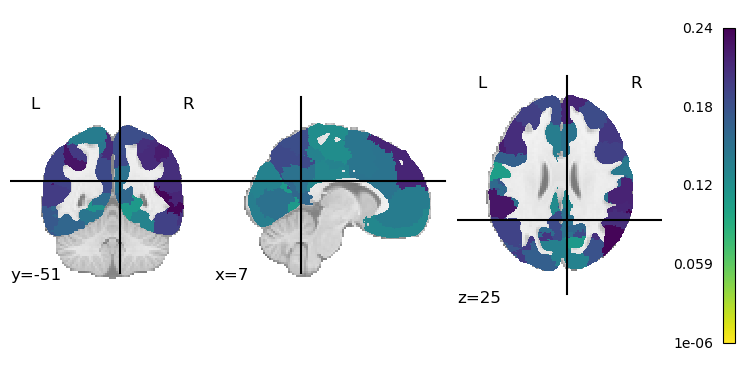

In [50]:
mask_img = nilearn.image.new_img_like(atlas, xcpd_atlas)
# mask_img.to_filename('xcpd_prob_nodes.nii.gz') 

plotting.plot_stat_map(
    mask_img, 
    cmap='viridis_r') 

plotting.show()